In [2]:
# automatically reload edited source code
%load_ext autoreload
%autoreload 2

# external package imports
import numpy as np
import pandas as pd
import os, pdb, glob, time, argparse
from os.path import exists, split, isdir, getsize
from sdo_clv_pipeline.sdo_plot import *

# internal package imports
from sdo_clv_pipeline.paths import root
from sdo_clv_pipeline.sdo_io import *
from sdo_clv_pipeline.sdo_process import *
from sdo_clv_pipeline.sdo_io import * 
import sdo_clv_pipeline

c:\Users\srugi\Documents\sdo-clv-pipeline\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# returns four sorted lists with the path to each of the file types
data_dir = os.path.join(root, "data")
print("root: ", root)
fits_dir = os.path.join(root, "data")
print(data_dir)
files = organize_IO(fits_dir, clobber=True, globexp="")
con_files, mag_files, dop_files, aia_files = files
# print(con_files)
#print(len(con_files))
# print(con_files)
# print(mag_files)
# print(dop_files)
# print(aia_files)


root:  C:\Users\srugi\Documents\sdo-clv-pipeline
C:\Users\srugi\Documents\sdo-clv-pipeline\data
[datetime.datetime(2014, 1, 15, 0, 0) datetime.datetime(2014, 1, 29, 0, 0)
 datetime.datetime(2014, 2, 12, 0, 0) datetime.datetime(2014, 2, 26, 0, 0)
 datetime.datetime(2014, 3, 12, 0, 0) datetime.datetime(2014, 3, 26, 0, 0)
 datetime.datetime(2014, 4, 9, 0, 0) datetime.datetime(2014, 4, 23, 0, 0)
 datetime.datetime(2014, 5, 7, 0, 0) datetime.datetime(2014, 6, 4, 0, 0)
 datetime.datetime(2014, 6, 18, 0, 0)]
[datetime.datetime(2014, 1, 15, 0, 0)
 datetime.datetime(2014, 1, 15, 12, 0)
 datetime.datetime(2014, 1, 29, 0, 0)
 datetime.datetime(2014, 1, 29, 12, 0)
 datetime.datetime(2014, 2, 12, 0, 0) datetime.datetime(2014, 2, 26, 0, 0)
 datetime.datetime(2014, 2, 26, 16, 0)
 datetime.datetime(2014, 3, 12, 0, 0)
 datetime.datetime(2014, 3, 12, 16, 0)
 datetime.datetime(2014, 3, 26, 0, 0)
 datetime.datetime(2014, 3, 26, 20, 0) datetime.datetime(2014, 4, 9, 0, 0)
 datetime.datetime(2014, 4, 23, 0, 

C:\Users\srugi\Documents\sdo-clv-pipeline\data\hmi.ic_720s.20140115_000000_TAI.1.continuum.fits
C:\Users\srugi\Documents\sdo-clv-pipeline\data\hmi.m_720s.20140115_000000_TAI.1.magnetogram.fits
C:\Users\srugi\Documents\sdo-clv-pipeline\data\hmi.v_720s.20140115_000000_TAI.1.Dopplergram.fits
C:\Users\srugi\Documents\sdo-clv-pipeline\data\aia_lev1_1700a_2014_01_15t00_00_30_71z_image_lev1.fits
C:\Users\srugi\Documents\sdo-clv-pipeline\data
>>> Running epoch 2014-01-15T00:00:00 


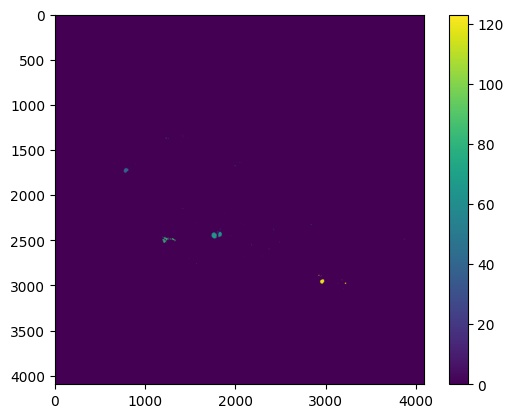

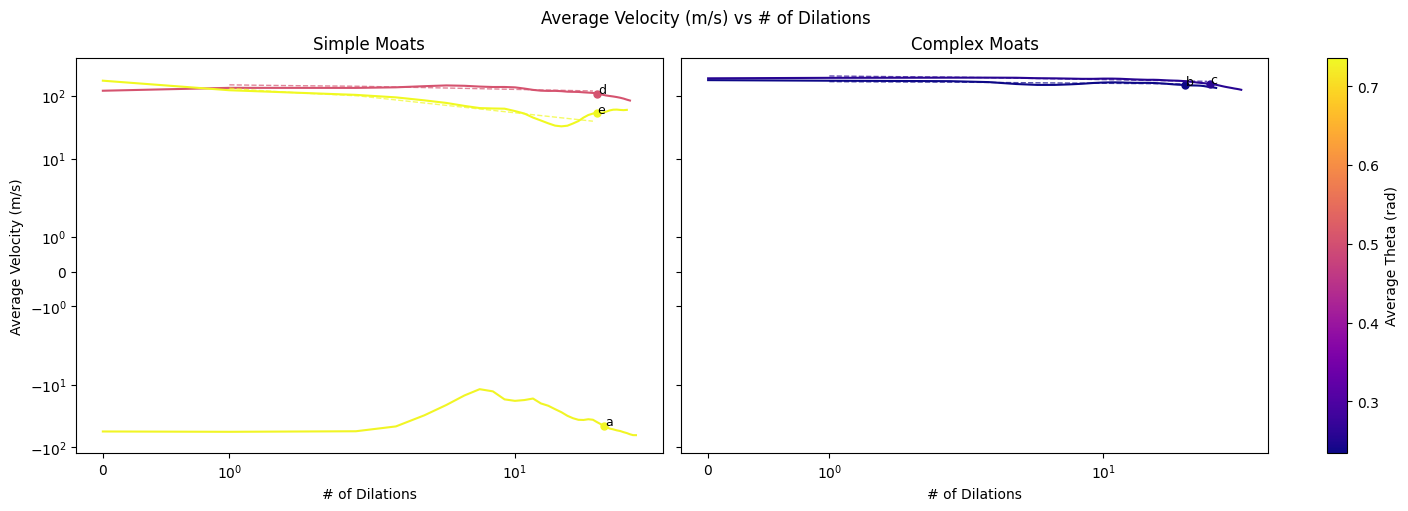

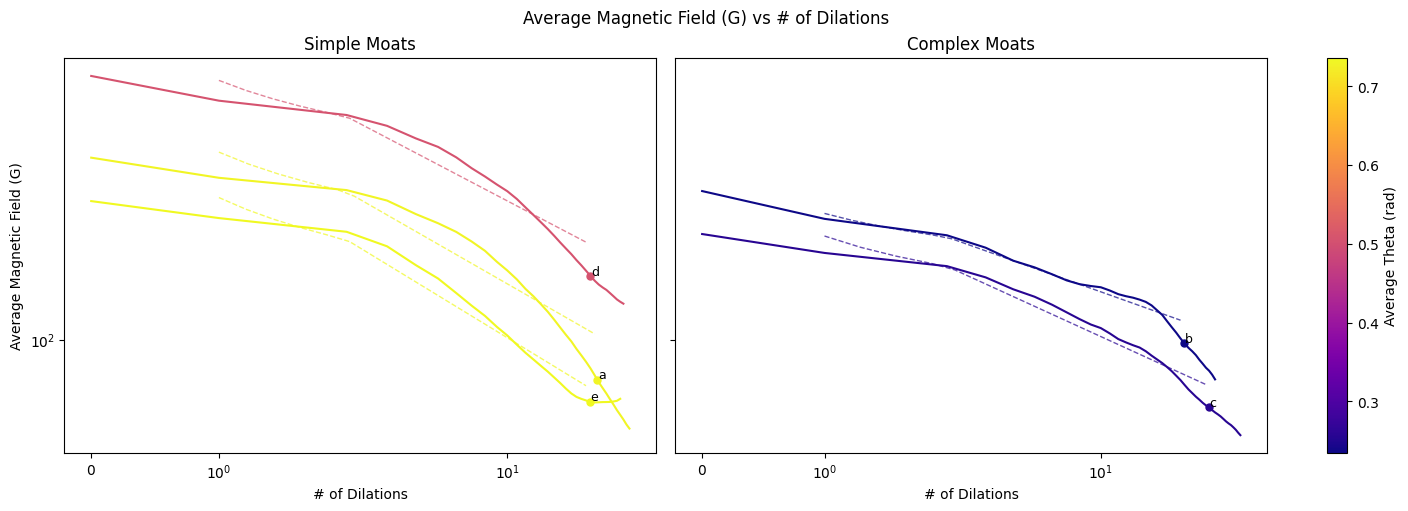

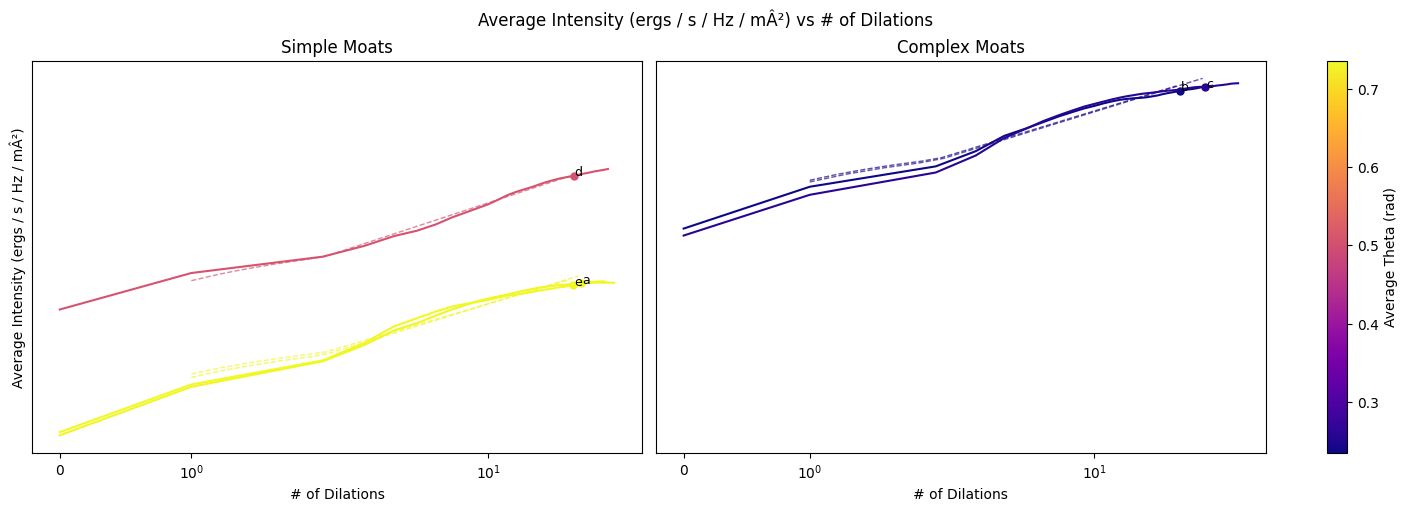

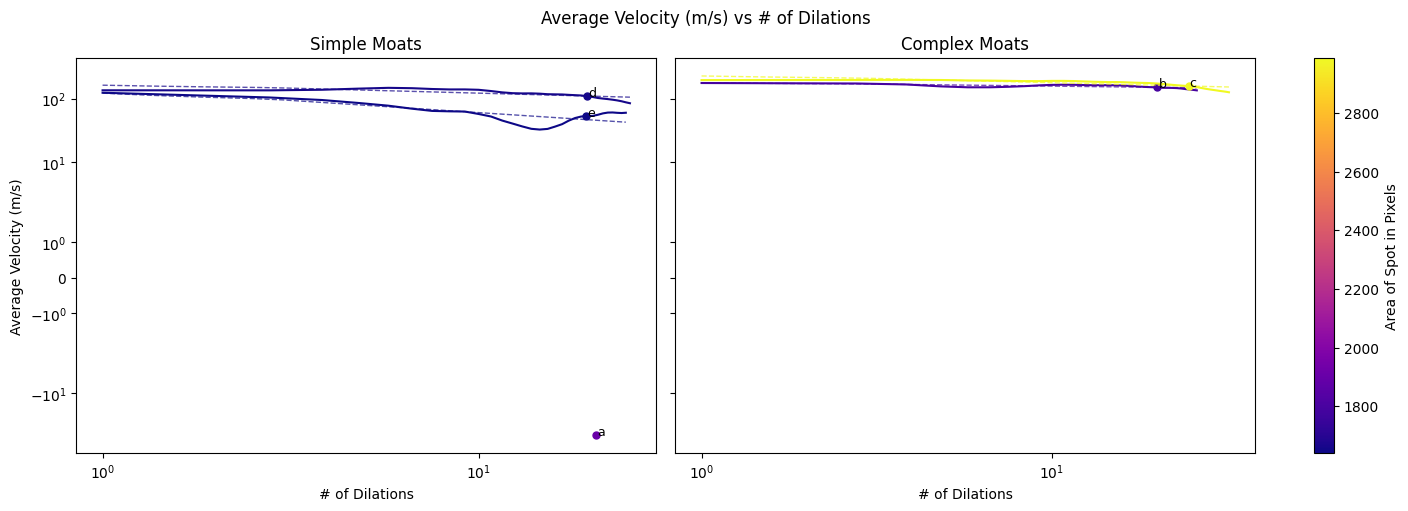

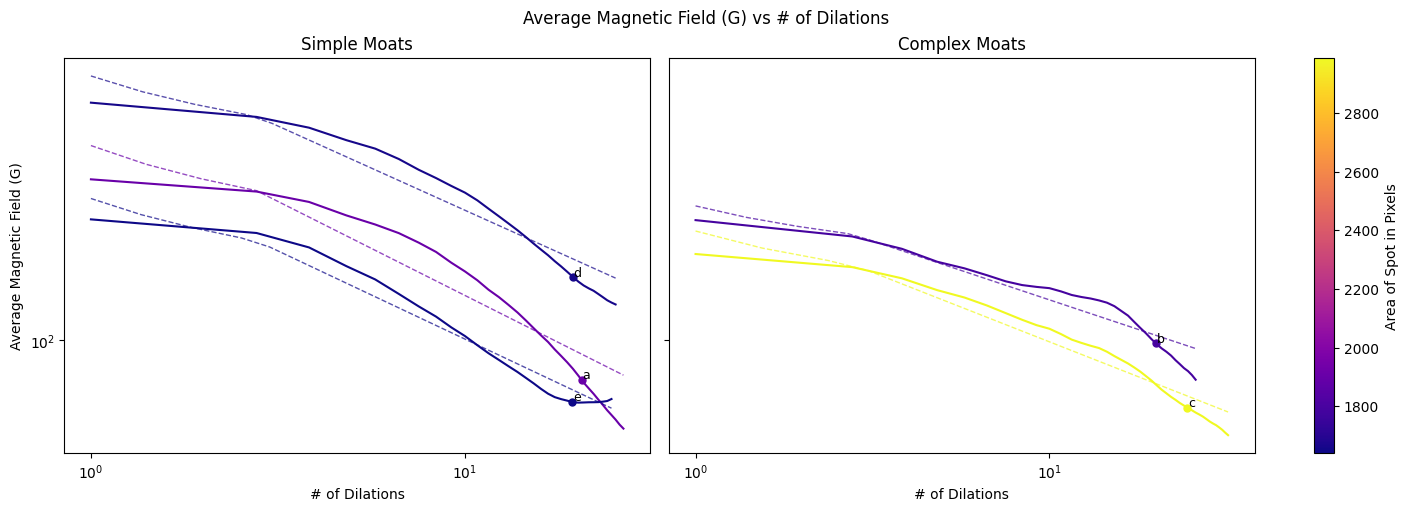

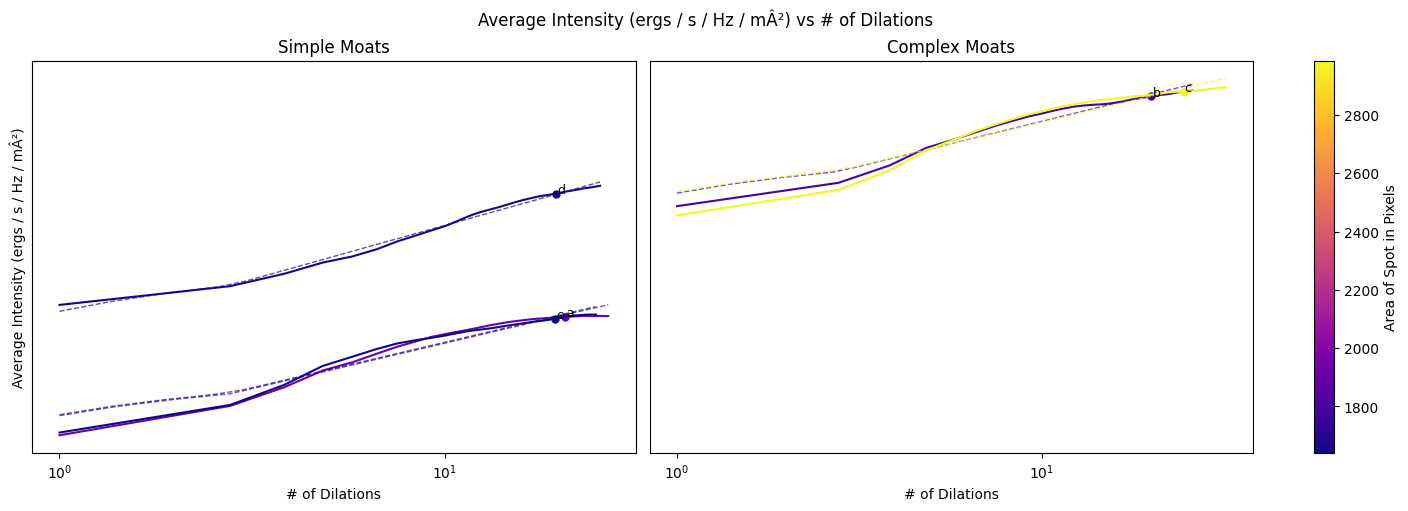

0.003834188254863367
good fit
0.026559840115177646
good fit
0.0012535784063976469
good fit
0.0011187409496968685
good fit
0.008820752121213513
good fit
0.0050510000328452265
good fit
0.003203606213568912
good fit
0.001089246013964933
good fit
0.002396095972735398
good fit
6.673834907069827e-06
good fit
2.018295838185175e-06
good fit
8.308652950295589e-06
good fit
5.890661941000813e-06
good fit
1.2030607620967272e-05
good fit


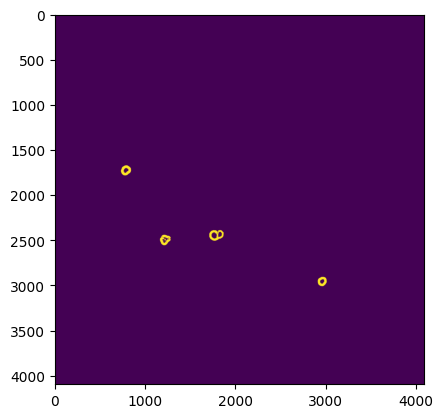

	 >>> Run successfully in 146.81781100004446 seconds
C:\Users\srugi\Documents\sdo-clv-pipeline\data\hmi.ic_720s.20140129_000000_TAI.1.continuum.fits
C:\Users\srugi\Documents\sdo-clv-pipeline\data\hmi.m_720s.20140129_000000_TAI.1.magnetogram.fits
C:\Users\srugi\Documents\sdo-clv-pipeline\data\hmi.v_720s.20140129_000000_TAI.1.Dopplergram.fits
C:\Users\srugi\Documents\sdo-clv-pipeline\data\aia_lev1_1700a_2014_01_29t00_00_30_71z_image_lev1.fits
C:\Users\srugi\Documents\sdo-clv-pipeline\data
>>> Running epoch 2014-01-29T00:00:00 


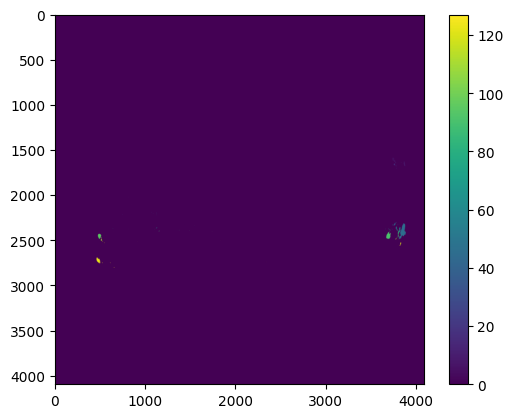

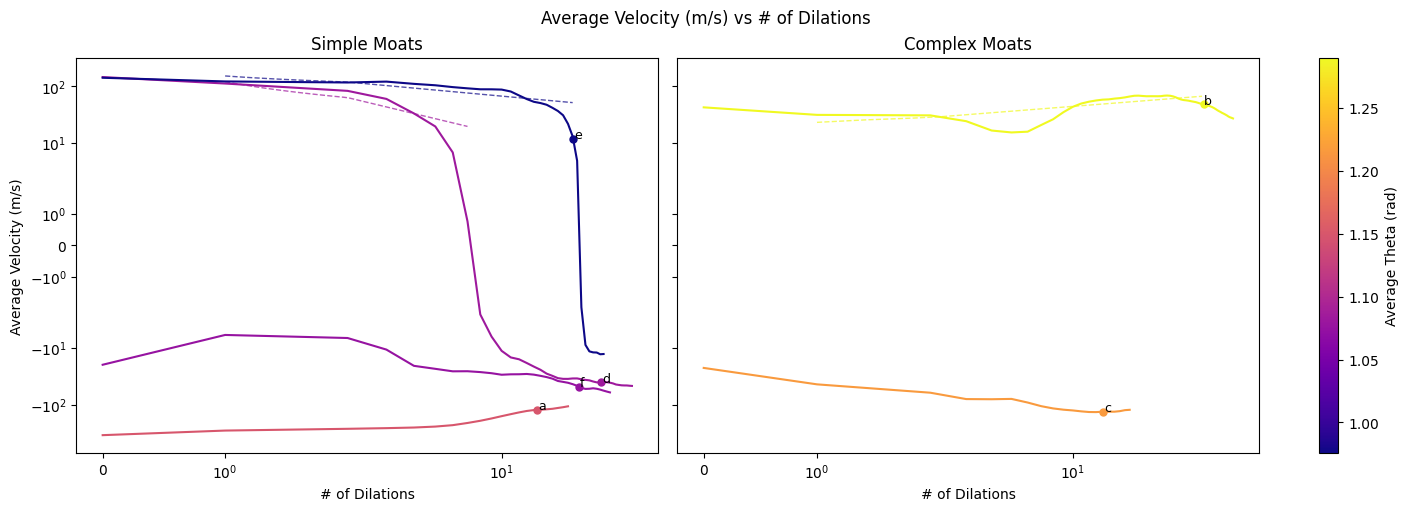

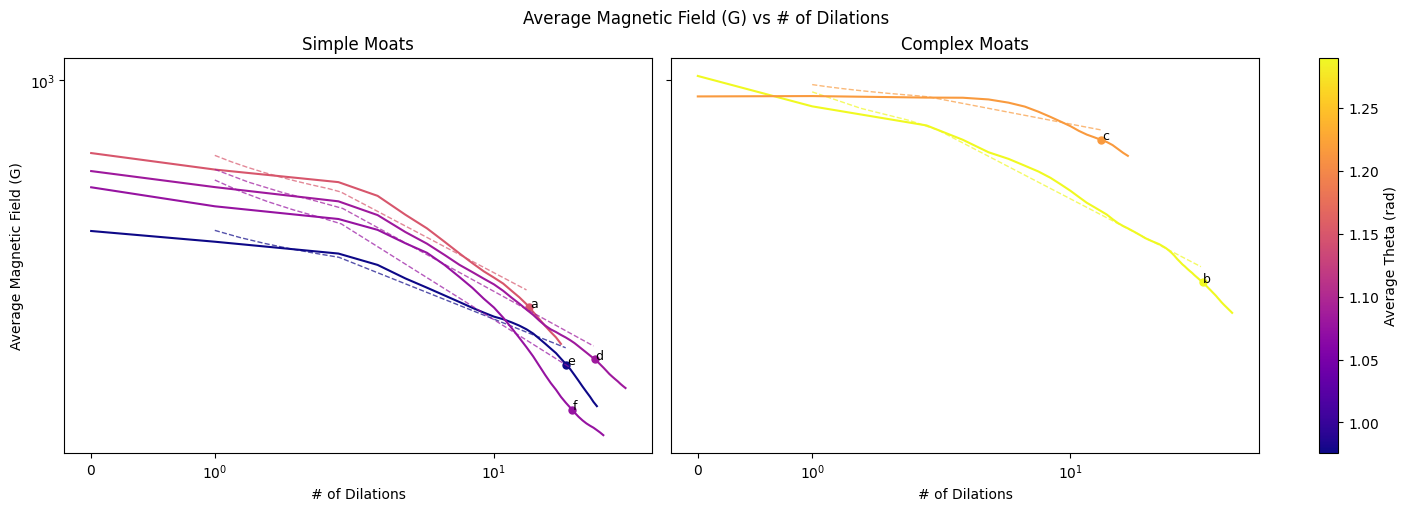

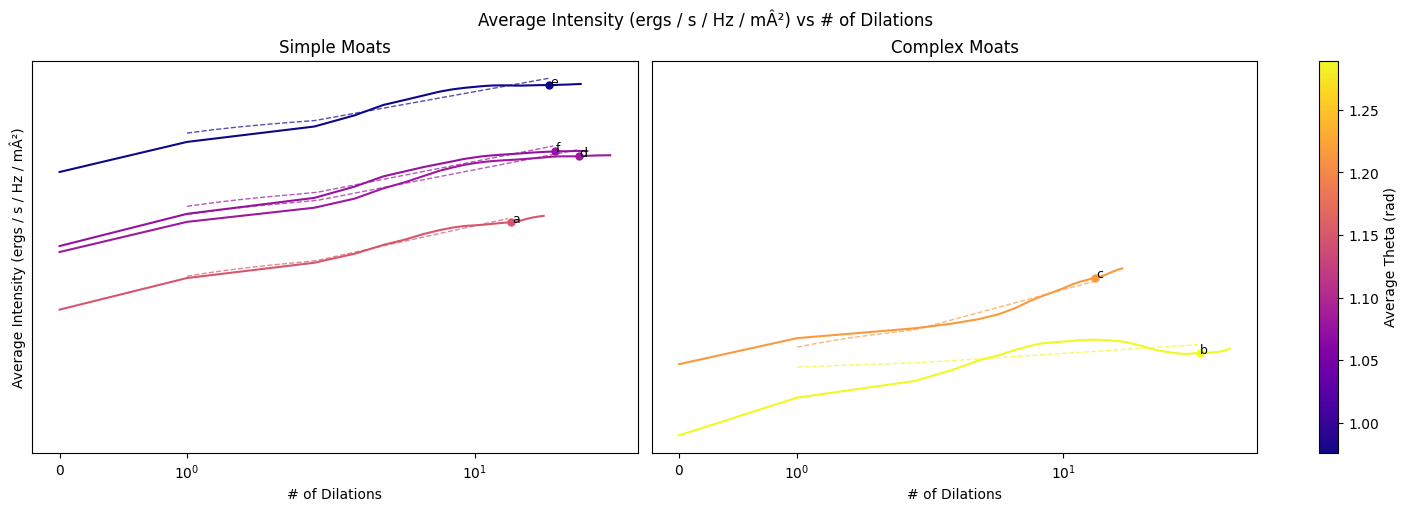

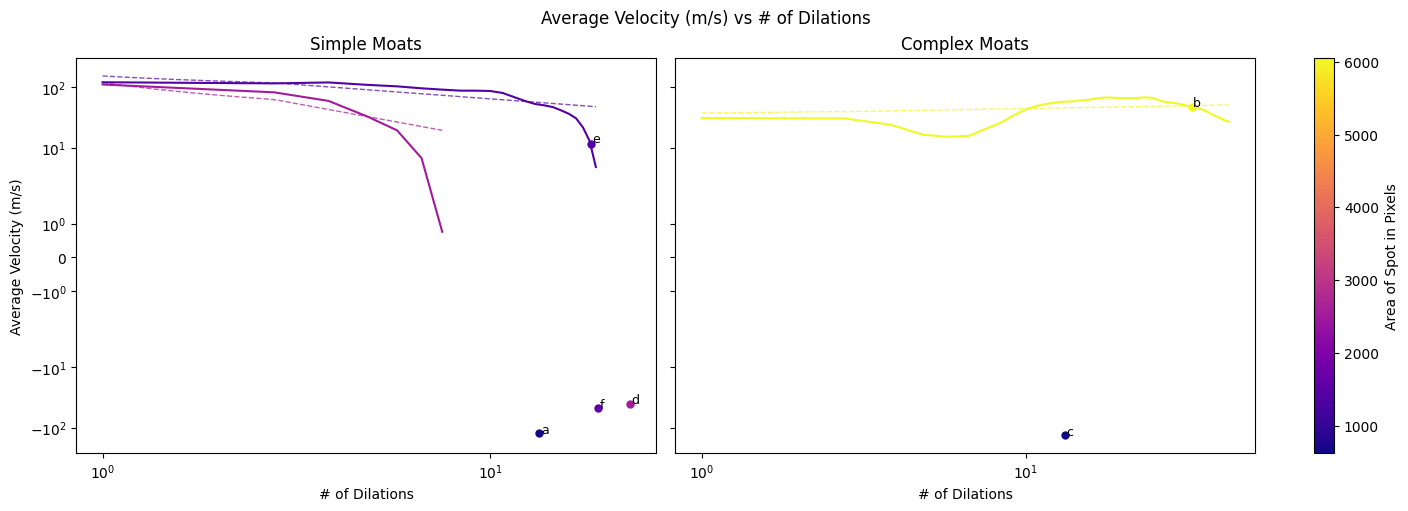

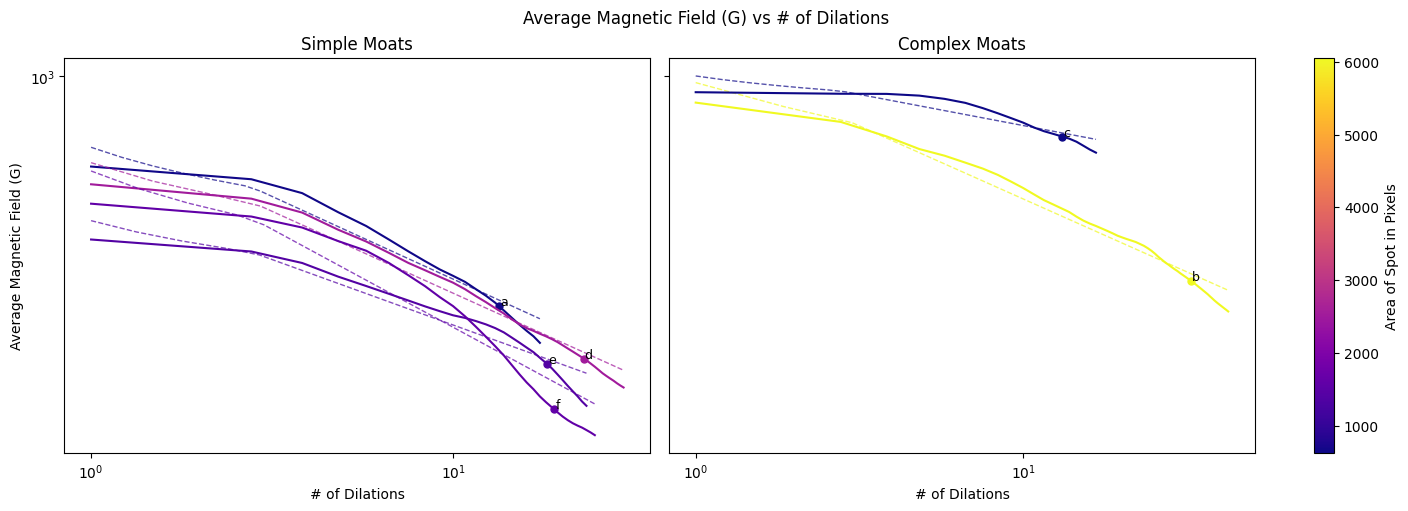

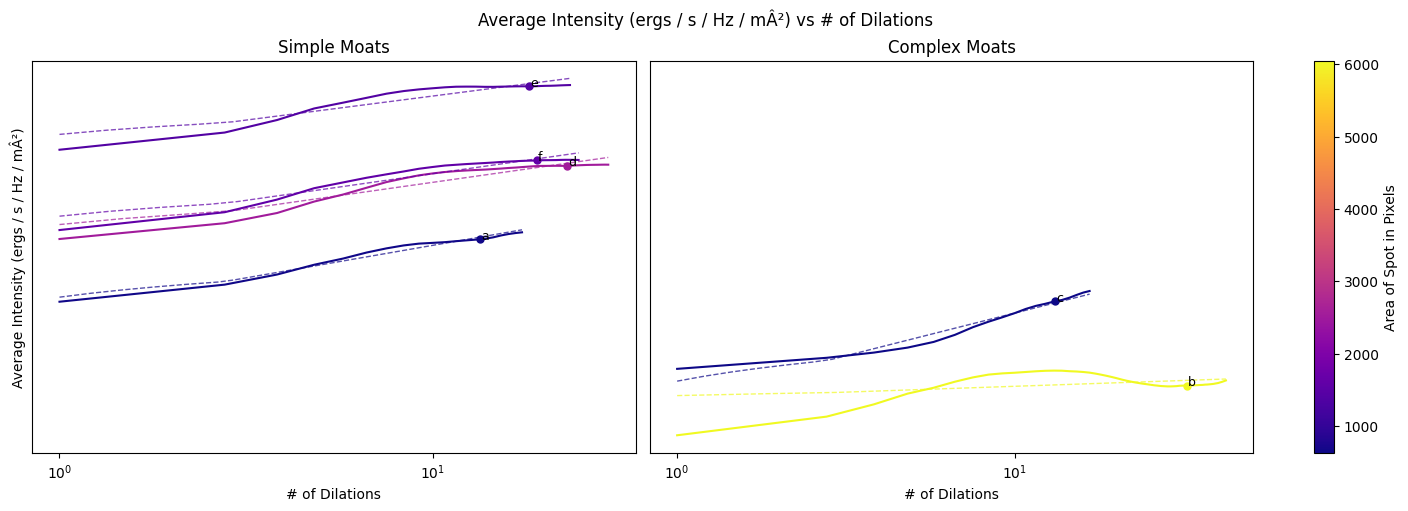

0.7626593362899018
bad fit
0.09767168418158147
good fit
0.07440060173828515
good fit
0.0020565192671954543
good fit
0.001433777685862497
good fit
0.0010695889758495264
good fit
0.009733370334652354
good fit
0.0010136371288241275
good fit
0.0014031034498357845
good fit
5.041715569983945e-06
good fit
1.8681596697342208e-05
good fit
2.1142107532712053e-05
good fit
1.3240347603626164e-05
good fit
8.272479310284398e-05
good fit
1.772320032114543e-05
good fit


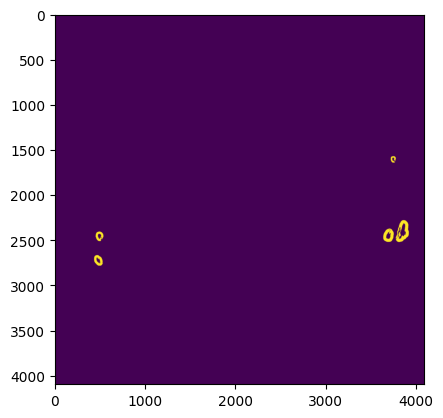

	 >>> Run successfully in 163.1260309999343 seconds


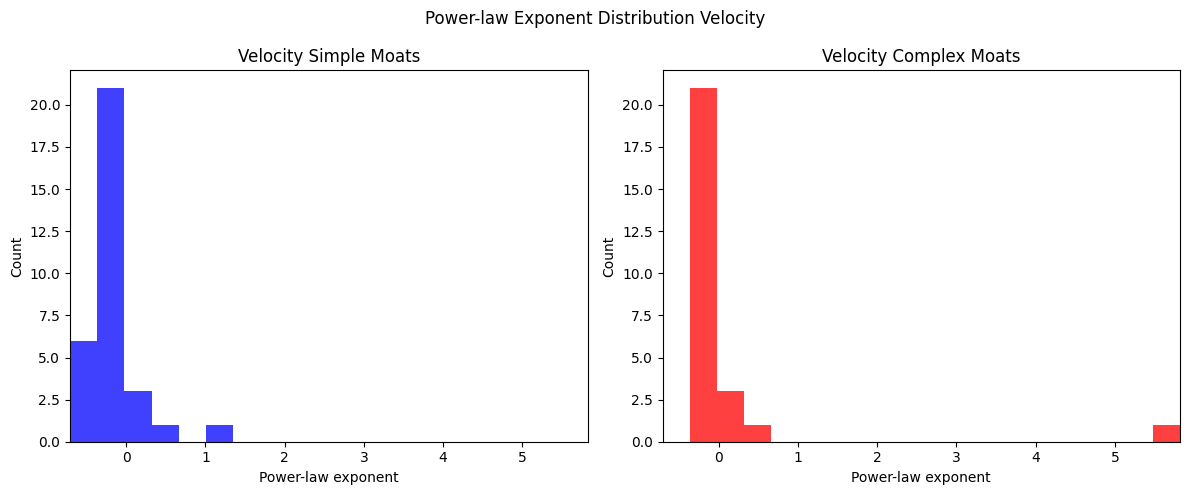

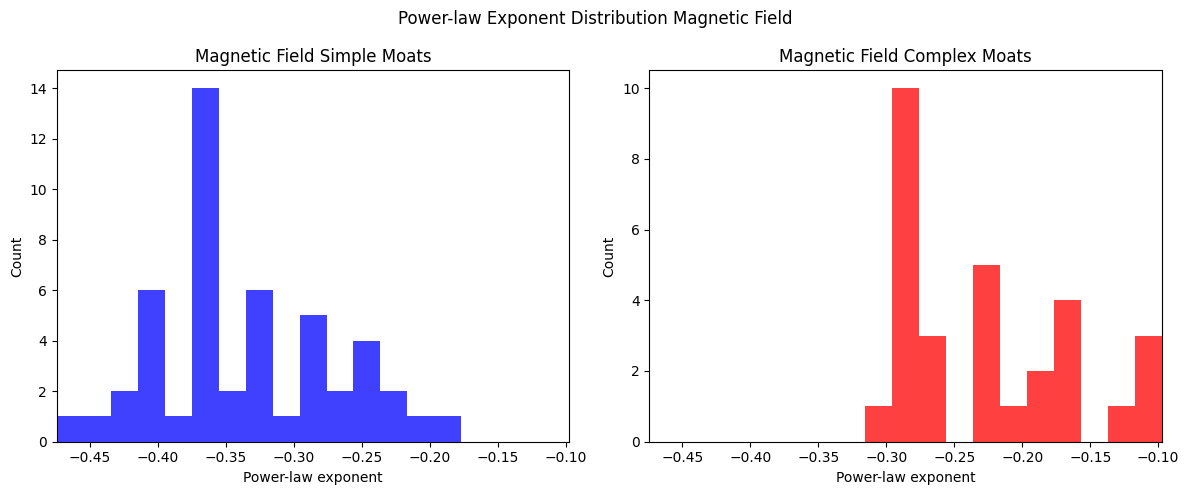

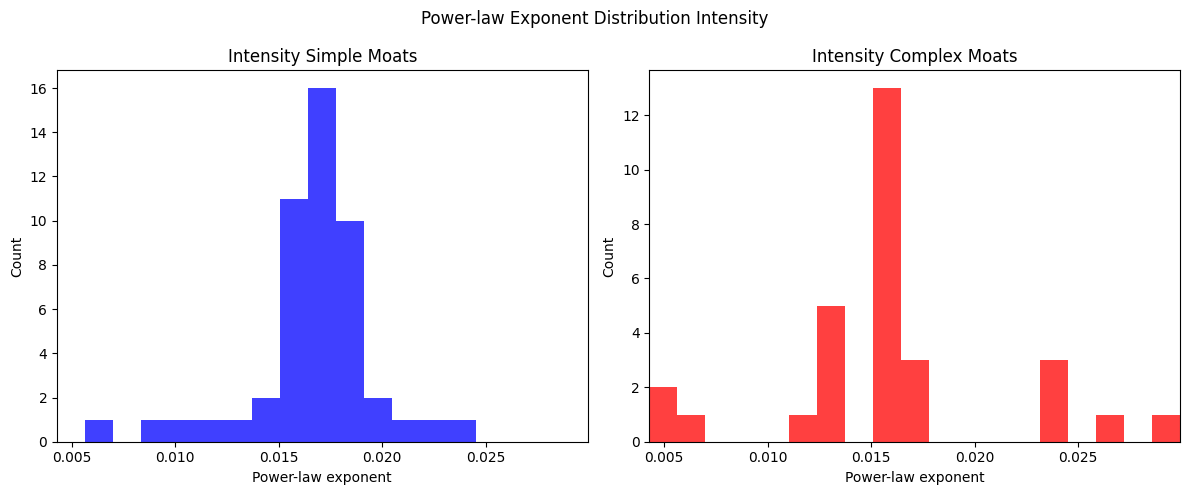

In [18]:
moat_vels = []
moat_mags = []
moat_ints = []
moat_dilations = []
moat_areas = []
moat_thetas = []
moat_vals = []
counter = -1
moat_avg_vels = []
symbol = []
left_moats = []
right_moats = []

#for i in range(len(con_files)):
for i in range(0, 2):
    # define the paths where files live
    con_file = os.path.join(data_dir, con_files[i])
    mag_file = os.path.join(data_dir, mag_files[i])
    dop_file = os.path.join(data_dir, dop_files[i])
    aia_file = os.path.join(data_dir, aia_files[i])
    print(con_file)
    print(mag_file)
    print(dop_file)
    print(aia_file)
    print(data_dir)

    # # create the SDOImage object instances
    # con = SDOImage(con_file)     # continuum, Relative HMI continuum intensity
    # mag = SDOImage(mag_file)     # magnetogram, magnetic field strength
    # dop = SDOImage(dop_file)     # Dopplergram, LOS velocity
    # aia = SDOImage(aia_file)     # AIA 1700 continuum filtergram, Relative 1700 Angstrom Continuum Intensity


    process_data_set(con_file, mag_file, dop_file, aia_file,
                     mu_thresh=0.1, n_rings=10, suffix=None, datadir=data_dir)

    # # do the coordinate transforms, etc.
    # dop.calc_geometry()
    # con.inherit_geometry(dop)
    # mag.inherit_geometry(dop)

    # aia.rescale_to_hmi(con) # reproject onto plate scale of HMI images

    # # calculate the limb darkening correction
    # con.calc_limb_darkening()
    # aia.calc_limb_darkening()

    # # correct magnetogram for foreshortening
    # mag.correct_magnetogram()

    # # calculate differential rot., meridional circ., obs. vel, grav. redshift, cbs
    # dop.correct_dopplergram(fit_cbs=False)

    # # set values to nan for mu less than mu_thresh
    # mu_thresh = 0.1
    # con.mask_low_mu(mu_thresh)
    # dop.mask_low_mu(mu_thresh)
    # mag.mask_low_mu(mu_thresh)
    # aia.mask_low_mu(mu_thresh)

    # counter += 1

    # mask = SunMask(con, mag, dop, aia, moat_vels, moat_mags, moat_ints, moat_dilations, moat_thetas, moat_areas, moat_vals, counter, moat_avg_vels, symbol)
    # mask.mask_low_mu(mu_thresh)

    # label_moats_on_sun(mask)

plot_moats_data.plot_final_histograms()

In [ ]:
#plot_mask(mask)
plt.imshow(mask.regions)


NameError: name 'mask' is not defined

In [ ]:
import sdo_clv_pipeline
print(sdo_clv_pipeline.__file__)
from sdo_clv_pipeline.paths import root
print(root)

/Users/mpalumbo/work/savannah/sdo-clv-pipeline/sdo_clv_pipeline/__init__.py
/Users/mpalumbo/work/savannah/sdo-clv-pipeline
